In [1]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import numpy as np
import matplotlib.pyplot as plt
import analytic_solution as AS
import diff_G as  diff

In [2]:
beta = 20.0
Ntau = 401
Ns = 2
Nw = 200
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [3]:
t_values_ED = np.linspace(0.0001, 2, 501)
order = 7
Gij_iwn_exact = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_exact_U = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_sce = np.zeros((order, len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((order, len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
U = 1
order = 7
for u in range(t_values_ED.size):
    Gij_iwn_exact[u] = AS.G_analytic(t_values_ED[u], wn*t_values_ED[u], U, beta/t_values_ED[u])
    Gij_iwn_exact_U[u] = 1/t_values_ED[u]*AS.G_analytic(1, wn, U/t_values_ED[u], beta)
    for d in range(order):
        Gij_iwn_wce[d, u] = diff.Gij_wce_series(d, t_values_ED[u],  U , wn*t_values_ED[u])
        Gij_iwn_sce[d, u] = diff.Gij_sce_series(d, t_values_ED[u],  U , wn*t_values_ED[u], beta/t_values_ED[u])

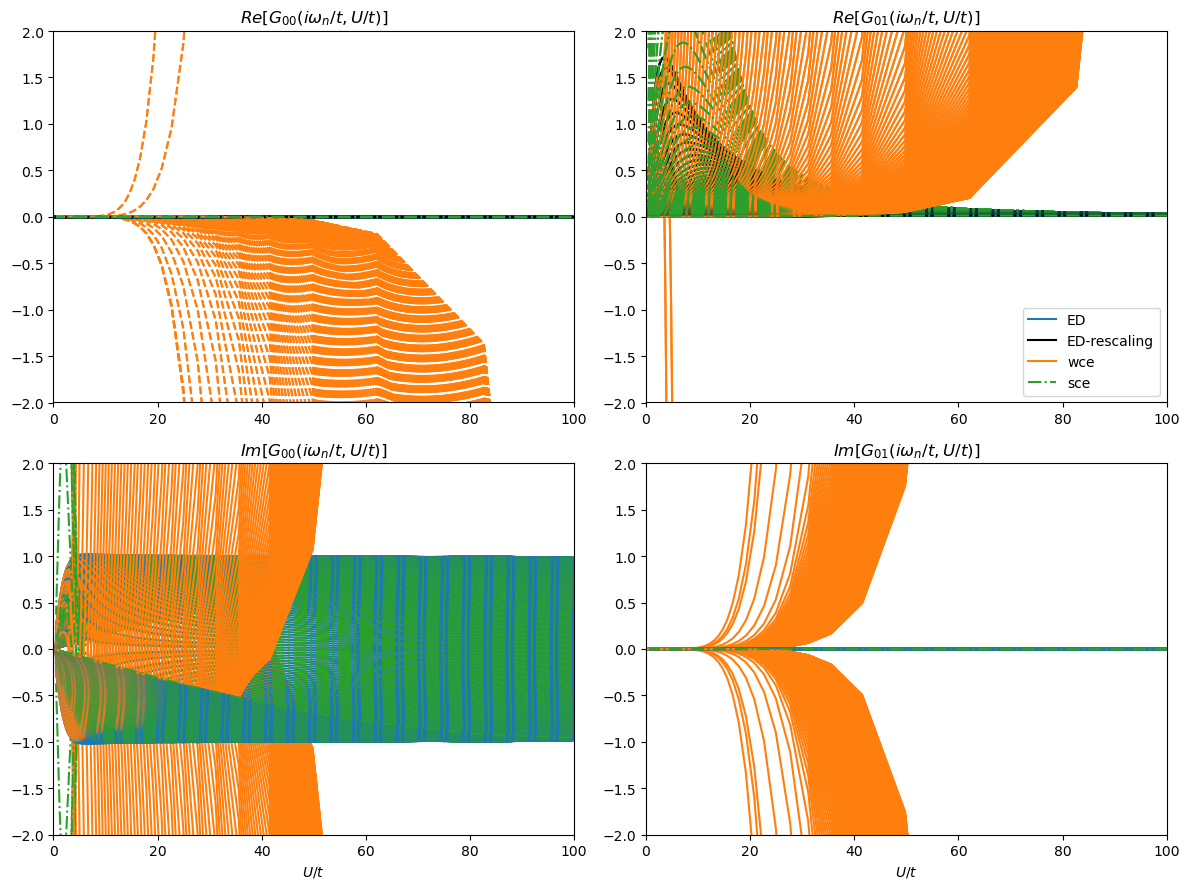

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(1/t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(1/t_values_ED, Gij_iwn_exact_U[:, i, 0, 0 ].real, 'k')
    ax11.plot(1/t_values_ED, Gij_iwn_wce[-1, :, i, 0, 0 ].real, 'C1--')
    ax11.plot(1/t_values_ED, Gij_iwn_sce[-1, :, i, 0, 0 ].real, 'C2-.')
ax11.set_title(r'$Re[G_{00}(i\omega_n/t, U/t)]$')
ax11.set_xlim([0,100])
ax11.set_ylim([-2,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(1/t_values_ED, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(1/t_values_ED, Gij_iwn_exact_U[:, i, 0,1 ].real, 'k')
    ax12.plot(1/t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].real, 'C1')
    ax12.plot(1/t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C2-.')

ax12.plot(1/t_values_ED, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'ED')
ax12.plot(1/t_values_ED, Gij_iwn_exact_U[:, i, 0,1 ].real, 'k', label = 'ED-rescaling')
ax12.plot(1/t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].real, 'C1', label = 'wce')
ax12.plot(1/t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C2-.', label = 'sce')
ax12.legend()
ax12.set_xlim([0,100])
ax12.set_ylim([-2,2])
ax12.set_title(r'$Re[G_{01}(i\omega_n/t,U/t)]$')

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(1/t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(1/t_values_ED, Gij_iwn_wce[-1,:, i, 0,0 ].imag, 'C1')
    ax21.plot(1/t_values_ED, Gij_iwn_sce[-1,:, i, 0,0].imag, 'C2-.')
ax21.set_xlim([0,100])
ax21.set_ylim([-2,2])
ax21.set_xlabel(r'$U/t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n/t,U/t)]$')

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(1/t_values_ED, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(1/t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].imag, 'C1')
    ax22.plot(1/t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].imag, 'C2-.')
ax22.set_xlim([0,100])
ax22.set_ylim([-2,2])
ax22.set_xlabel(r'$U/t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n/t, U/t)]$')

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

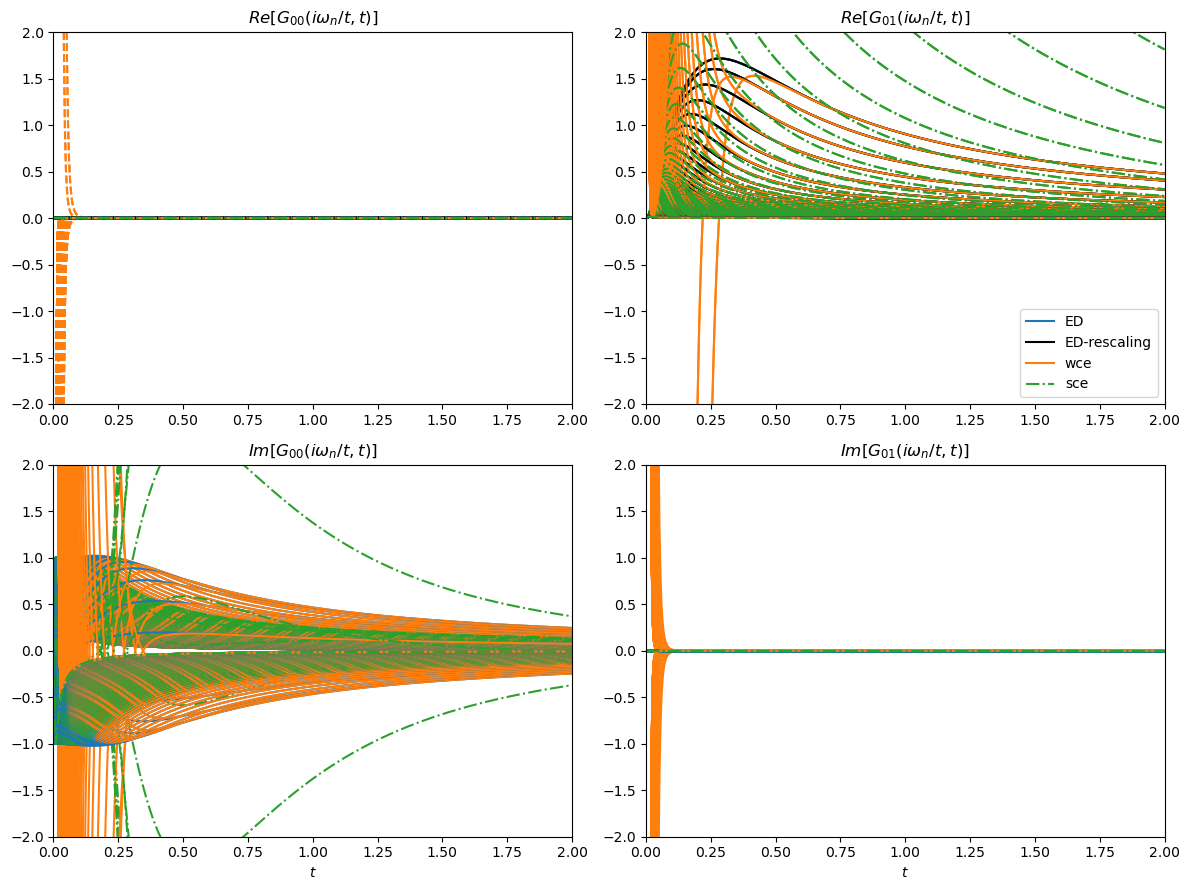

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(t_values_ED, Gij_iwn_exact_U[:, i, 0, 0 ].real, 'k')
    ax11.plot(t_values_ED, Gij_iwn_wce[-1, :, i, 0, 0 ].real, 'C1--')
    ax11.plot(t_values_ED, Gij_iwn_sce[-1, :, i, 0, 0 ].real, 'C2-.')
ax11.set_title(r'$Re[G_{00}(i\omega_n/t, t)]$')
ax11.set_xlim([0,2])
ax11.set_ylim([-2,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(t_values_ED, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(t_values_ED, Gij_iwn_exact_U[:, i, 0,1 ].real, 'k')
    ax12.plot(t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].real, 'C1')
    ax12.plot(t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C2-.')

ax12.plot(t_values_ED, Gij_iwn_exact[:, i, 0,1 ].real, 'C0', label = 'ED')
ax12.plot(t_values_ED, Gij_iwn_exact_U[:, i, 0,1 ].real, 'k', label = 'ED-rescaling')
ax12.plot(t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].real, 'C1', label = 'wce')
ax12.plot(t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C2-.', label = 'sce')
ax12.legend()
ax12.set_xlim([0,2])
ax12.set_ylim([-2,2])
ax12.set_title(r'$Re[G_{01}(i\omega_n/t,t)]$')

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(t_values_ED, Gij_iwn_wce[-1,:, i, 0,0 ].imag, 'C1')
    ax21.plot(t_values_ED, Gij_iwn_sce[-1,:, i, 0,0].imag, 'C2-.')
ax21.set_xlim([0,2])
ax21.set_ylim([-2,2])
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n/t,t)]$')

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(t_values_ED, Gij_iwn_wce[-1,:, i, 0,1 ].imag, 'C1')
    ax22.plot(t_values_ED, Gij_iwn_sce[-1,:, i, 0,1 ].imag, 'C2-.')
ax22.set_xlim([0,2])
ax22.set_ylim([-2,2])
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n/t, t)]$')

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

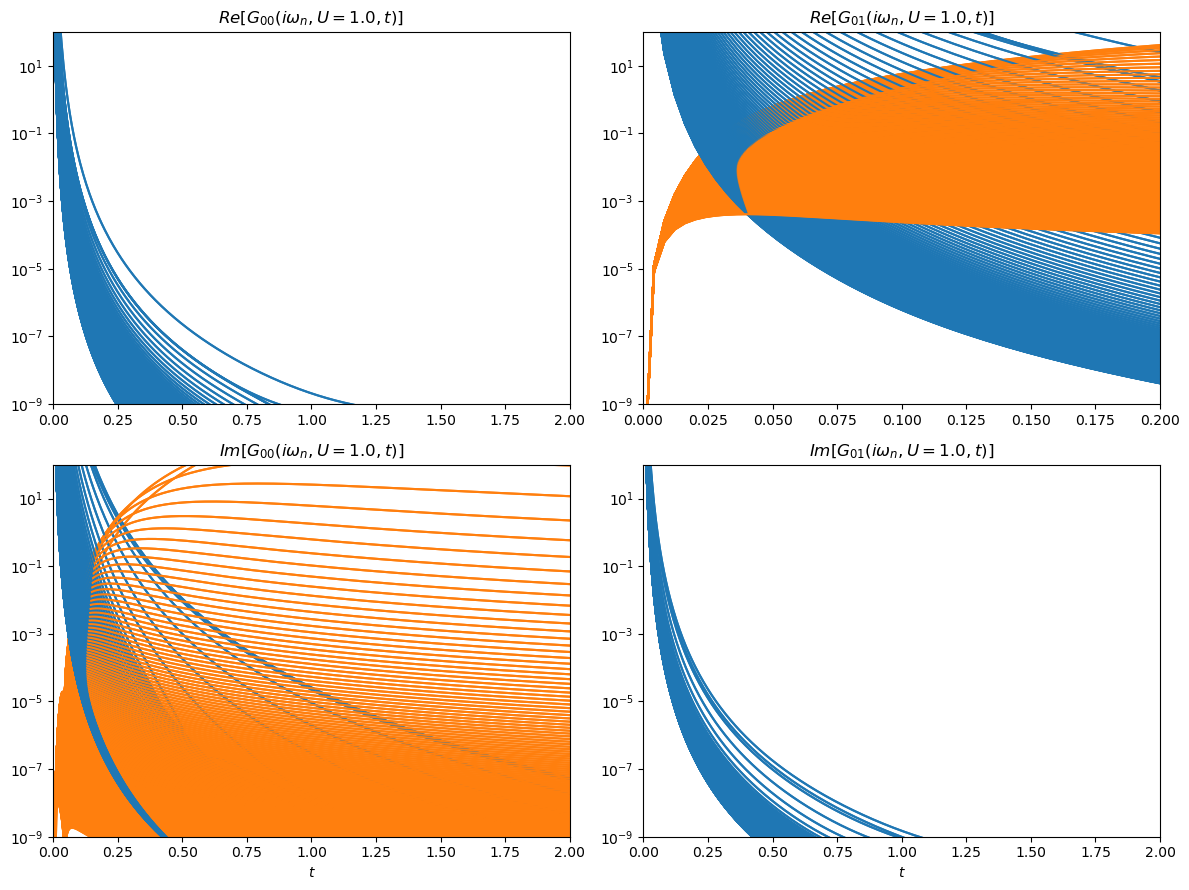

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 0 ].real-Gij_iwn_wce[-1, :, i, 0, 0 ].real), 'C0')
    ax11.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 0 ].real-Gij_iwn_sce[-1,:, i, 0, 0 ].real), 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_xlim([0, 2])
ax11.set_ylim([1e-9,100])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0,1 ].real-Gij_iwn_wce[-1, :, i, 0,1 ].real), 'C0')
    ax12.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0,1 ].real-Gij_iwn_sce[-1, :, i, 0,1 ].real), 'C1')
ax12.set_xlim([0,0.2])
ax12.set_ylim([1e-9,100])
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 0 ].imag-Gij_iwn_wce[-1,:, i, 0,0 ].imag), 'C0')
    ax21.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 0 ].imag-Gij_iwn_sce[-1,:, i, 0,0 ].imag), 'C1')
ax21.set_xlim([0,2])
ax21.set_ylim([1e-9,100])
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 1 ].imag-Gij_iwn_wce[-1,:, i, 0,1 ].imag), 'C0')
    ax22.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, i, 0, 1 ].imag-Gij_iwn_sce[-1,:, i, 0,1 ].imag), 'C1')
ax22.set_xlim([0,2])
ax22.set_ylim([1e-9,100])
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

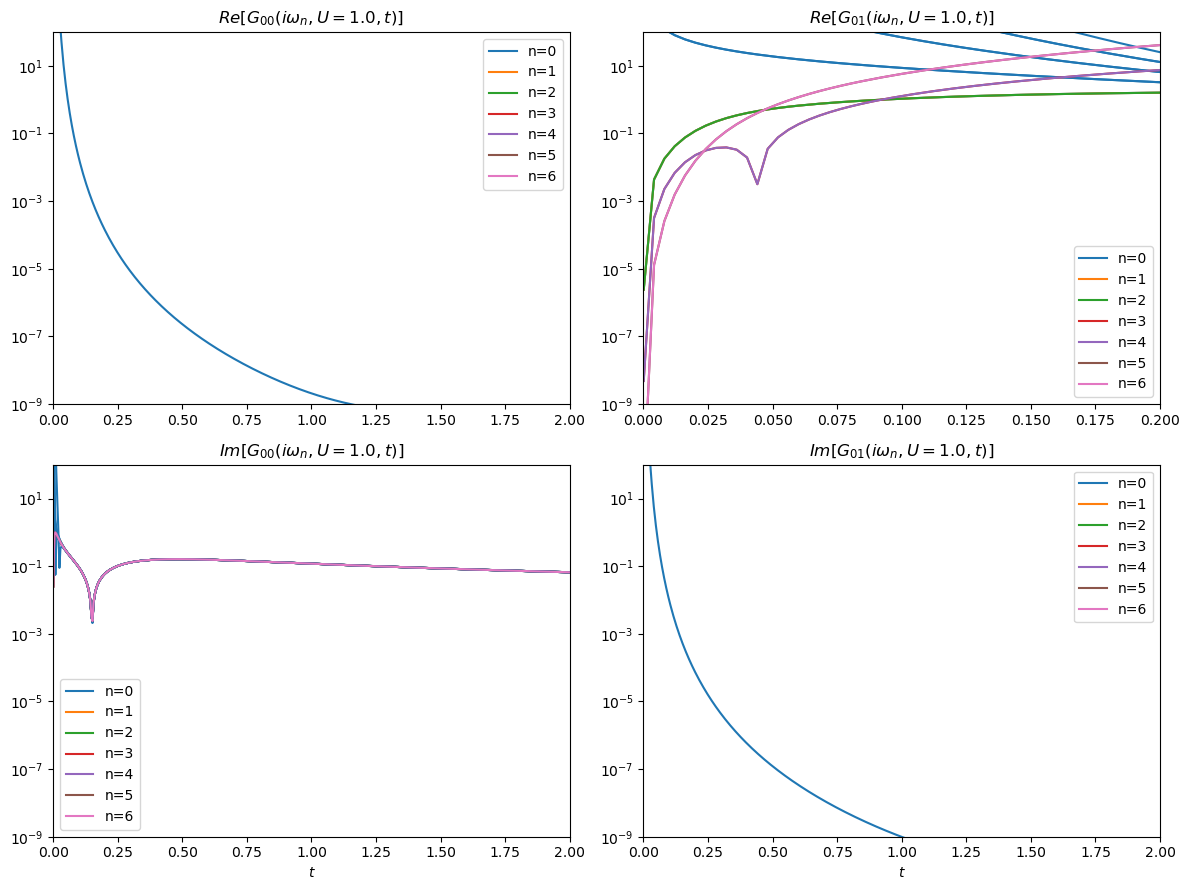

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

wn_id = Nw
# (1,1) — like your figure(1)
for d in range(order):
    ax11.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 0 ].real-Gij_iwn_wce[d, :, wn_id , 0, 0 ].real), 'C0')
    ax11.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 0 ].real-Gij_iwn_sce[d, :, wn_id , 0, 0 ].real), label = 'n=%d'%d)
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.legend()
ax11.set_xlim([0, 2])
ax11.set_ylim([1e-9,100])
# (1,2) — like your figure(2)
for d in range(order):
    ax12.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0,1 ].real-Gij_iwn_wce[d,:, wn_id , 0,1 ].real), 'C0')
    ax12.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0,1 ].real-Gij_iwn_sce[d,:, wn_id , 0,1 ].real), label = 'n=%d'%d)
ax12.set_xlim([0,0.2])
ax12.set_ylim([1e-9,100])
ax12.legend()
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for d in range(order):
    ax21.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 0 ].imag-Gij_iwn_wce[d,:, i, 0,0 ].imag), 'C0')
    ax21.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 0 ].imag-Gij_iwn_sce[d,:, i, 0,0 ].imag), label = 'n=%d'%d)
ax21.set_xlim([0,2])
ax21.legend()
ax21.set_ylim([1e-9,100])
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for d in range(order):
    ax22.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 1 ].imag-Gij_iwn_wce[d,:, wn_id , 0,1 ].imag), 'C0')
    ax22.semilogy(t_values_ED, np.abs(Gij_iwn_exact[:, wn_id , 0, 1 ].imag-Gij_iwn_sce[d,:, wn_id , 0,1 ].imag), label = 'n=%d'%d)
ax22.set_xlim([0,2])
ax22.set_ylim([1e-9,100])
ax22.legend()
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

In [8]:
# import utilities as ut 

# t_test = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
# Gij_tau_exact = np.zeros((len(t_test), Ntau, 2, 2))
# for t in range(len(t_test)):
#     print(t)
#     t_id = np.argmin(t_values_ED- t_test[t])
#     Gij_tau_exact[t] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_exact[t_id]/t_test[t], wn, np.linspace(0, beta, Ntau), beta))




0
1
2
3
4
5
